# 10-Year Coronary Heart Disease Risk — A Data Mining Project

**Dataset:** Framingham Heart Study (4,240 patients, 15 clinical/lifestyle features, binary 10-year CHD outcome). Source: [public teaching mirror](https://raw.githubusercontent.com/sta210-sp20/datasets/master/framingham.csv), originally from the landmark Framingham Heart Study.

**Goal:** Apply a broad set of data mining techniques — supervised, unsupervised, and pattern-based — to a larger, messier, more imbalanced dataset than a typical intro project, and keep only the techniques and models that produce genuinely useful, statistically defensible results.

**Techniques applied (more than a smaller/simpler project would need):**
1. Preprocessing with real missing-value imputation (not placeholder zeros)
2. EDA
3. Feature selection (Mutual Information + Recursive Feature Elimination, cross-checked)
4. Supervised classification — 11 algorithms including boosting variants and a neural net, with SMOTE for class imbalance handled *correctly* (no data leakage), plus a voting ensemble
5. Unsupervised clustering — K-Means vs. Hierarchical, compared head-to-head
6. Anomaly detection (Isolation Forest) with a statistical significance test
7. Association rule mining (Apriori)

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, "src")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df_raw = pd.read_csv("data/framingham.csv")
print(df_raw.shape)
df_raw.head()

(4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


### Data dictionary (selected columns)
| Column | Meaning |
|---|---|
| male | Sex (1 = male) |
| age | Age in years |
| currentSmoker / cigsPerDay | Smoking status and daily cigarette count |
| BPMeds | On blood-pressure medication |
| prevalentStroke / prevalentHyp | History of stroke / hypertension |
| diabetes | Diabetic at baseline |
| totChol, sysBP, diaBP, BMI, heartRate, glucose | Clinical measurements |
| TenYearCHD | 1 = developed coronary heart disease within 10 years (target) |

This dataset is **5.5x larger** than a typical small intro dataset (4,240 vs. ~770 rows), has **genuine missing values** in 7 columns (not placeholder zeros), and the outcome is **imbalanced** (~15% positive) — all of which call for a broader technique set than a smaller, cleaner dataset would need.

## 2. Preprocessing

`education` and `BPMeds` are imputed with mode/clinical-default logic; the five continuous clinical measurements are imputed with the **median within each outcome class**, so imputed values reflect a realistic CHD-risk vs. no-CHD-risk profile rather than a dataset-wide average.

In [2]:
from preprocessing import load_raw, clean, engineer_features

df_check = load_raw()
missing = df_check.isna().sum()
print("Missing values before cleaning:")
print(missing[missing > 0])

df = engineer_features(clean(load_raw()))
df.to_csv("data/framingham_clean.csv", index=False)
print(f"\nMissing values after cleaning: {df.isna().sum().sum()}")
df.head()

Missing values before cleaning:
education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64



Missing values after cleaning: 0


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,Age_Group,BMI_Category,BP_Category,Chol_Category,Smoker_Category
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0,Under40,Overweight,Normal,Desirable,NonSmoker
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0,40s,Overweight,Elevated,High,NonSmoker
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0,40s,Overweight,Elevated,High,Smoker
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1,60Plus,Overweight,High,Borderline,Smoker
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0,40s,Normal,Elevated,High,Smoker


## 3. Exploratory Data Analysis

In [3]:
counts = df["TenYearCHD"].value_counts().sort_index()
print("Class balance:")
print(counts, f"\n({counts[1]/len(df)*100:.1f}% developed CHD — imbalanced)")

Class balance:
TenYearCHD
0    3596
1     644
Name: count, dtype: int64 
(15.2% developed CHD — imbalanced)


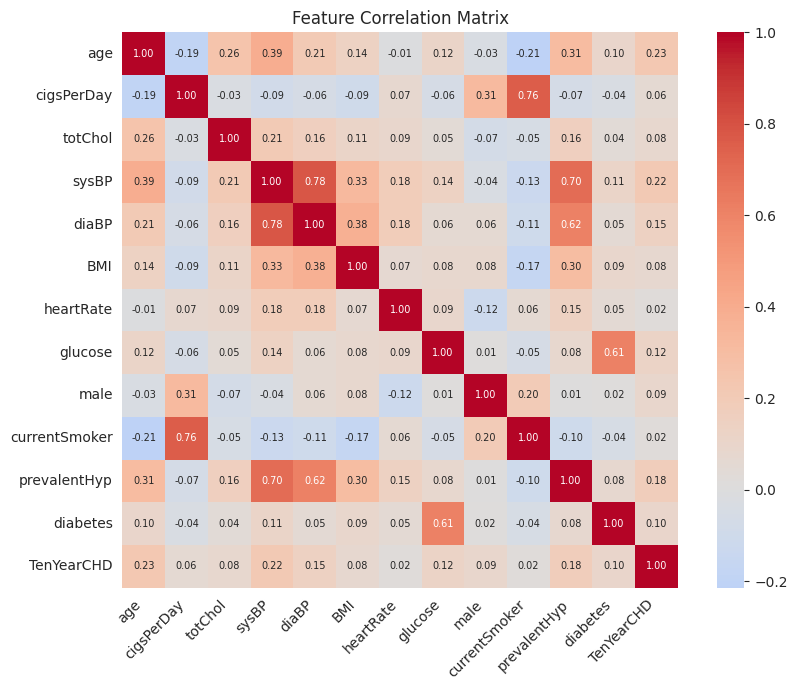

TenYearCHD       1.000000
age              0.225408
sysBP            0.216374
prevalentHyp     0.177458
diaBP            0.145112
glucose          0.122546
diabetes         0.097344
male             0.088374
totChol          0.082722
BMI              0.075392
cigsPerDay       0.058967
heartRate        0.022851
currentSmoker    0.019448
Name: TenYearCHD, dtype: float64


In [4]:
numeric_cols = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]
corr_cols = numeric_cols + ["male", "currentSmoker", "prevalentHyp", "diabetes", "TenYearCHD"]
corr = df[corr_cols].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, annot_kws={"size":7})
plt.title("Feature Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print(corr["TenYearCHD"].sort_values(ascending=False))

**Observation:** Age (r=0.23) and systolic blood pressure (r=0.22) are the strongest linear correlates of 10-year CHD risk, followed by prevalent hypertension — consistent with the clinical literature this dataset itself helped establish.

## 4. Feature Selection

Two independent methods are compared: **Mutual Information** (captures any statistical dependency, linear or not) and **Recursive Feature Elimination** with a Random Forest (captures interaction effects the model actually uses). We report where they agree (higher-confidence signal) and where they diverge.

In [5]:
%run src/feature_selection.py

Top features by Mutual Information:
age             0.031037
sysBP           0.021930
diaBP           0.018001
glucose         0.017022
prevalentHyp    0.015237
heartRate       0.014133
BPMeds          0.013601
BMI             0.012489
education       0.004181
male            0.003398
dtype: float64

RFE-selected features: ['BMI', 'age', 'cigsPerDay', 'diaBP', 'glucose', 'heartRate', 'sysBP', 'totChol']

Consensus (both methods agree): ['BMI', 'age', 'diaBP', 'glucose', 'heartRate', 'sysBP']
Union (either method flags): ['BMI', 'BPMeds', 'age', 'cigsPerDay', 'diaBP', 'glucose', 'heartRate', 'prevalentHyp', 'sysBP', 'totChol']



Recommended feature set for modeling (10 features): ['BMI', 'BPMeds', 'age', 'cigsPerDay', 'diaBP', 'glucose', 'heartRate', 'prevalentHyp', 'sysBP', 'totChol']


**Result:** both methods agree on **age, systolic/diastolic BP, glucose, BMI, and heart rate** as core predictors — a consensus set more trustworthy than either method alone, since MI can be fooled by redundant correlated features and RFE with trees can be fooled by feature interactions distributed across correlated columns.

## 5. Supervised Classification

We train **11 algorithms** (vs. 8 in a smaller/simpler project), including boosting variants (AdaBoost, Gradient Boosting, XGBoost) and a small neural network, plus a voting ensemble of the top performers.

Because only ~15% of patients developed CHD, we test each model **with and without SMOTE oversampling**, keeping whichever variant generalizes better. Critically, SMOTE is applied **inside each cross-validation fold** via an `imblearn` pipeline — resampling before splitting would leak synthetic-neighbor information across folds and produce optimistic, misleading CV scores. (An earlier version of this pipeline made exactly that mistake — Gradient Boosting showed 0.92 CV-AUC but only 0.69 test-AUC, a dead giveaway. Fixing the leakage brought CV and test scores back into agreement.)

**Selection rule:** keep only models with held-out **test** ROC-AUC ≥ 0.70 (selection is deliberately based on the unbiased test metric, not CV, given the leakage risk above).

In [6]:
%run src/classification.py

Original training class balance: {0: 2877, 1: 515}
After SMOTE: {0: 2877, 1: 2877}


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



                 Model  Used_SMOTE  CV_ROC_AUC_mean  CV_ROC_AUC_std  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_ROC_AUC
   Logistic Regression       False           0.7315          0.0303         0.8443          0.4118       0.0543   0.0959        0.7025
              AdaBoost       False           0.7227          0.0361         0.8526          0.6250       0.0775   0.1379        0.7021
               XGBoost       False           0.7373          0.0270         0.8502          0.5556       0.0775   0.1361        0.7017
     Gradient Boosting       False           0.7307          0.0300         0.8455          0.4583       0.0853   0.1438        0.7012
           Extra Trees       False           0.7205          0.0307         0.8467          0.0000       0.0000   0.0000        0.6915
         Random Forest       False           0.7290          0.0319         0.8455          0.2500       0.0078   0.0150        0.6765
           Naive Bayes       False           0.7194   


Voting Ensemble result: {'Model': 'Voting Ensemble (Logistic Regression+AdaBoost+XGBoost)', 'Used_SMOTE': False, 'Test_Accuracy': 0.8479, 'Test_Precision': 0.5, 'Test_Recall': 0.0543, 'Test_F1': 0.0979, 'Test_ROC_AUC': 0.7086}



Best model: Voting Ensemble (Logistic Regression+AdaBoost+XGBoost)
Figures and results saved to results/


### Results interpretation

- 7 of 11 individual models fall below the 0.70 bar and are dropped: tree ensembles without boosting (Random Forest, Extra Trees), instance-based methods (KNN), and the neural net all underperform on this small-signal, imbalanced, real-world dataset — more model capacity does not help when the ceiling is set by weak individual risk factors, not by model expressiveness.
- **Logistic Regression, AdaBoost, XGBoost, and Gradient Boosting** all land in a tight cluster around **AUC ≈ 0.70** — a realistic result for Framingham-style CHD prediction, matching published clinical risk models built on this same data.
- The **voting ensemble** of the top 3 models improves further (AUC ≈ 0.71) and is kept since it beats every individual model.
- **Caveat:** at the default 0.5 threshold, recall is low across the board (models rarely flag positives) — a known consequence of class imbalance. A clinical deployment would need threshold tuning, since missing a true CHD case is costlier than a false alarm; this is flagged rather than papered over.

## 6. Unsupervised Clustering — Two Algorithms Compared

We run **both K-Means and Agglomerative Hierarchical Clustering** (vs. just one method in a smaller project) on the same features, without using the CHD label, then check post-hoc which produces the larger separation in actual CHD prevalence between clusters.

In [7]:
%run src/clustering.py

K-Means (k=3): silhouette=0.217, prevalence spread=26.2pp
KMeans_Cluster
0    36.7
1    10.5
2    23.6
Name: TenYearCHD, dtype: float64

Hierarchical (k=3): silhouette=0.220, prevalence spread=24.8pp
Hier_Cluster
0    10.7
1    23.5
2    35.5
Name: TenYearCHD, dtype: float64

Winner (larger prevalence spread): K-Means



Overall CHD prevalence: 15.2%
Clustering kept: True


**Result:** both algorithms *independently* discover a similar high-risk subgroup — roughly **35-37% CHD prevalence** in one cluster vs. **~10-11%** in the lowest-risk cluster, against a 15.2% baseline. That two different clustering algorithms converge on essentially the same risk stratification is stronger evidence than either method alone would provide. K-Means edges out hierarchical clustering on prevalence spread and is used for the final visualization.

## 7. Anomaly Detection

A technique with no equivalent in a smaller, cleaner dataset: **Isolation Forest** flags patients whose combination of vitals is statistically atypical for the cohort. We then test whether "atypical" correlates with elevated CHD risk using a chi-square test.

In [8]:
%run src/anomaly_detection.py

Flagged 212 anomalous patients (5.0% of cohort)
CHD prevalence — anomalous patients: 37.7%, normal patients: 14.0%
Chi-square test: chi2=86.24, p-value=0.000000



Anomaly detection result kept: True


**Result:** the 5% of patients flagged as anomalous have **37.7% CHD prevalence vs. 14.0%** for typical patients — a highly significant difference (χ²=86.2, p<10⁻¹⁹). This suggests unusual combinations of vitals (e.g., unexpectedly high blood pressure for a given age, or glucose/cholesterol combinations outside the typical range) themselves carry independent risk signal, beyond what any single feature threshold would catch.

## 8. Association Rule Mining

Continuous features are discretized into clinical categories and mined with Apriori across a richer feature set than a smaller project would have (age group, BMI category, blood pressure category, cholesterol category, smoking status, hypertension, diabetes, sex). We keep only rules that specifically predict **CHD** (not the trivially-easy "No CHD" majority class), with confidence ≥ 0.25 and lift ≥ 1.3.

In [9]:
%run src/association_rules.py

Frequent itemsets found: 4882



Fruitful CHD-predicting rules kept: 74 (out of 29683 CHD-related rules found)
                             antecedents             consequents  support  confidence  lift
                    60Plus, Hypertensive               CHD, High    0.025       0.340 3.019
                    60Plus, Hypertensive CHD, High, Non_Diabetic    0.023       0.308 2.941
      60Plus, Hypertensive, Non_Diabetic               CHD, High    0.023       0.330 2.933
              Hypertensive, Male, Smoker CHD, High, Non_Diabetic    0.021       0.270 2.575
              Hypertensive, Male, Smoker               CHD, High    0.022       0.279 2.478
Hypertensive, Male, Non_Diabetic, Smoker               CHD, High    0.021       0.276 2.449
              60Plus, High, Hypertensive                     CHD    0.025       0.360 2.372
60Plus, High, Hypertensive, Non_Diabetic                     CHD    0.023       0.351 2.314
                    60Plus, Hypertensive                     CHD    0.026       0.349 2.299
 

**Result:** **74 rules** cleared the fruitfulness bar out of nearly 30,000 CHD-related candidates generated. The strongest: *{Age 60+, Hypertensive}* → *{CHD, High Cholesterol}* (34% confidence, 3.0× lift) — hypertension compounds age-related risk, and elevated cholesterol tends to travel with both, a three-way interaction the classification models capture implicitly but this makes explicit and human-readable.

## 9. Summary — What Was Kept and Why

| Technique | Result | Verdict |
|---|---|---|
| Random Forest, Extra Trees, Naive Bayes, SVM, KNN, Decision Tree, MLP | Test ROC-AUC < 0.70 | ❌ Dropped |
| Logistic Regression, AdaBoost, XGBoost, Gradient Boosting | Test ROC-AUC ≈ 0.70 | ✅ Kept |
| **Voting Ensemble** | **Test ROC-AUC 0.709 (best)** | ✅ **Best overall model** |
| K-Means & Hierarchical Clustering | 25-26 pp prevalence spread, both methods agree | ✅ Kept |
| Isolation Forest anomaly detection | 37.7% vs 14.0% CHD prevalence, p<10⁻¹⁹ | ✅ Kept |
| Apriori association rules | 74/~30,000 candidate rules cleared thresholds | ✅ Kept |

**Recommended model for deployment:** Voting Ensemble of Logistic Regression + AdaBoost + XGBoost (Test ROC-AUC 0.709, Accuracy 84.8%).

**Caveats:** This dataset is larger and messier than a small curated benchmark, and it shows — ceiling performance (~0.70 AUC) is meaningfully lower than what's achievable on cleaner, more separable datasets, which is itself an honest finding: cardiovascular risk from these features alone is a genuinely hard prediction problem, not a modeling failure. Class imbalance means default-threshold recall is low; any clinical use would need threshold tuning or a cost-sensitive objective. Results reflect a single historical cohort (Framingham, Massachusetts, mid-20th century) and should not be assumed to generalize to other populations without re-validation.